# Analyse dataset OcWikiDialects

In [1]:
import ipywidgets

In [2]:
import os
import sqlite3
import warnings
from collections import Counter, defaultdict

In [3]:
import pandas as pd
import regex as re

In [4]:
import matplotlib.pyplot as plt
plt.style.use("paper.mplstyle")

In [5]:
%matplotlib inline

In [6]:
plots_folder = "plots"
os.makedirs(plots_folder, exist_ok=True)

# Load data

In [7]:
path = "ocwikidialects.jsonl"
df = pd.read_json(
    path, orient="records", lines=True, 
    dtype={"oc_level_first": "str", "oc_level_max": "str"},
    convert_dates=["date_creation", "date_latest_xml", "date_latest_finewiki"]
)
print(f"Loaded {len(df)} articles of the OcWikiDialects dataset.")
df.head()

Loaded 7292 articles of the OcWikiDialects dataset.


,id,title,dialect,text_xml,text_finewiki,paragraphs,segments,len_bytes_creation,len_bytes_latest,date_creation,...,user_rank_freq,user_rank_size,oc_level_first,oc_level_max,oc_level_rank_freq,oc_level_rank_size,bot_created,bot_first_author,bot_nb_revisions,user_dialects
0,1,Animalia,vivaroaupenc,{{1000 fondamentals}}\n{{Dialècte Vivaroaupenc...,# Animalia\nExemples d'animaus de classas divè...,[# Animalia\nExemples d'animaus de classas div...,"[# Animalia, Exemples d'animaus de classas div...",21,12675,2003-11-01,...,"{'6858': 28, '402': 19, '130': 18, '4312': 15,...","{'6858': 12350, '130': 7502, '15965': 1616, '9...",2,4,"{'null': 140, '2': 30, '4': 11, '0': 6}","{'2': 12375, 'null': 11723, '4': 335, '0': 169}",0,0,124,"[gascon, lengadocian, provençau]"
1,3,Vila,lengadocian,{{1000 fondamentals}}\n{{Dialècte Lengadocian}...,"# Vila\nUna vila (var. viala, viela, vièla gas...","[# Vila\nUna vila (var. viala, viela, vièla ga...","[# Vila, Una vila (var., viala, viela, vièla g...",50,31269,2003-07-18,...,"{'6858': 104, '224': 22, '128': 11, '189': 8, ...","{'6858': 56196, '239': 15562, '130': 6814, '22...",None,4,"{'2': 107, 'null': 96, '4': 14, '1': 2}","{'2': 56298, '4': 15591, 'null': 12453, '1': 314}",0,0,73,"[gascon, lengadocian, provençau]"
2,10,Frederic Mistral,provençau,{{Dialècte Provençau}}\n\n{{Omon|Mistral}}\n\n...,"# Frederic Mistral\n Frederic Mistral, o de ma...","[# Frederic Mistral\n Frederic Mistral, o de m...","[# Frederic Mistral, Frederic Mistral, o de ma...",73,12535,2003-10-24,...,"{'null': 31, '207': 28, '279': 23, '128': 12, ...","{'441': 4062, '279': 2286, '207': 1581, '15965...",None,5,"{'null': 160, '4': 42, '1': 17, '2': 7, '5': 5...","{'null': 13418, '4': 2952, '1': 902, '5': 403,...",0,0,54,"[auvernhat, gascon, lengadocian, provençau]"
3,23,Mammalia,provençau,{{1000 fondamentals}}\n{{Dialècte Provençau}}\...,# Mammalia\nMamifèrs de divèrses òrdres\nClass...,[# Mammalia\nMamifèrs de divèrses òrdres\nClas...,"[# Mammalia, Mamifèrs de divèrses òrdres, Clas...",24,31363,2003-11-01,...,"{'6858': 94, '130': 14, '402': 11, '4312': 9, ...","{'6858': 28772, '130': 8217, 'null': 2386, '15...",None,4,"{'null': 134, '2': 97, '4': 5, '0': 4, '1': 1}","{'2': 28820, 'null': 17800, '0': 112, '4': 30,...",0,0,103,"[gascon, lengadocian, provençau]"
4,34,Trobador,lengadocian,{{Dialècte Lengadocian}}\n{{Projècte educatiu|...,# Trobador\nUn trobador èra un poèta cantaire ...,[# Trobador\nUn trobador èra un poèta cantaire...,"[# Trobador, Un trobador èra un poèta cantaire...",77,8273,2003-10-31,...,"{'null': 21, '239': 20, '37340': 12, '128': 9,...","{'130': 6266, '37340': 1310, 'null': 1038, '15...",None,4,"{'null': 61, '4': 29, '2': 14, '3': 5, '1': 3}","{'null': 8733, '2': 1346, '4': 239, '3': 86, '...",0,0,25,"[lengadocian, provençau]"


In [8]:
# Print all columns of the dataset
print(f"Fields of the dataset: {df.columns.to_list()}")

Fields of the dataset: ['id', 'title', 'dialect', 'text_xml', 'text_finewiki', 'paragraphs', 'segments', 'len_bytes_creation', 'len_bytes_latest', 'date_creation', 'date_latest_xml', 'date_latest_finewiki', 'latest_revision_id', 'nb_revisions', 'nb_contributors', 'user_creator_id', 'user_latest_id', 'user_most_contrib_id', 'user_biggest_contrib_id', 'user_rank_freq', 'user_rank_size', 'oc_level_first', 'oc_level_max', 'oc_level_rank_freq', 'oc_level_rank_size', 'bot_created', 'bot_first_author', 'bot_nb_revisions', 'user_dialects']


# Load DB

In [9]:
# Fetch all users from DB
db_path = "file:ocwikidialects.sqlite?mode=ro"
db_con = sqlite3.connect(db_path)
df_users = pd.read_sql("SELECT * FROM user", db_con)

In [10]:
# Mark active users
active_user_ids = pd.read_sql("SELECT DISTINCT(user_id) as user_id FROM contribution WHERE user_id IS NOT NULL", db_con)
active_user_ids = set(active_user_ids["user_id"].tolist())
df_users["is_active"] = df_users["id"].isin(active_user_ids)
ratio_active = len(active_user_ids) / len(df_users)
print(f"{len(active_user_ids)} active users (at least 1 contribution), out of {len(df_users)}, i.e. {ratio_active:.2%}")
df_users.head()

1249 active users (at least 1 contribution), out of 1827, i.e. 68.36%


,id,username,oc_level,dialect,is_bot,is_active
0,0,imported>80.58.36.42.proxycache.rima-tde.net,None,None,0,True
1,3,Shaihulud,None,None,0,False
2,4,Gnu thomas~ocwiki,None,None,0,True
3,5,Youssefsan,None,None,0,False
4,7,Llull~ocwiki,None,None,0,True


# Basic stats

In [11]:
# Print number of articles
print(f"{len(df)} articles")

7292 articles


In [12]:
# Count paragraphs
df["n_pars"] = df["paragraphs"].apply(lambda pars: len(pars) if pars else 0)
total_pars = int(df["n_pars"].sum())
print(f"{total_pars=}")

total_pars=57385


In [13]:
# Count segments
df["n_segs"] = df["segments"].apply(lambda sents: len(sents) if sents else 0)
total_sents = int(df["n_segs"].sum())
print(f"{total_sents=}")

total_sents=289698


In [14]:
# Count tokens
def count_tokens(text):
    if not text:
        return 0
    toks = [t for t in text.split() if not re.fullmatch(r"[[:punct:]]+", t.strip())]
    # toks = text.split()
    return len(toks)

df["n_toks"] = df["text_finewiki"].apply(count_tokens)
total_toks = int(df["n_toks"].sum())
print(f"{total_toks=}")

total_toks=4037911


,n_toks
count,7292.000000
mean,553.745337
std,1015.811829
min,0.000000
25%,140.000000
50%,278.000000
75%,459.250000
max,14546.000000


Text(0.5, 1.0, 'Length of articles in tokens')

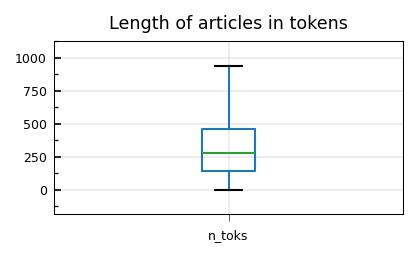

In [15]:
# Length of articles (in tokens)
display(df[["n_toks"]].describe())
ax = df[["n_toks"]].boxplot(showfliers=False)
ax.set_title("Length of articles in tokens")

# Articles history

,date_creation,date_latest_finewiki
count,7292,7257
mean,2013-09-22 18:03:33.274821632,2024-02-20 13:34:44.993799168
min,2003-07-18 00:00:00,2015-06-13 00:00:00
25%,2008-10-27 00:00:00,2023-09-11 00:00:00
50%,2011-10-25 00:00:00,2024-03-22 00:00:00
75%,2020-04-11 00:00:00,2024-12-24 00:00:00
max,2025-08-17 00:00:00,2025-08-20 00:00:00


Text(0.5, 1.0, 'Dates of articles')

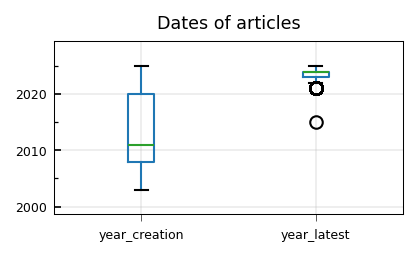

In [16]:
# Dates of articles
display(df[["date_creation", "date_latest_finewiki"]].describe())
df["year_creation"] = df.apply(lambda row: row["date_creation"].year, axis=1)
df["year_latest"] = df.apply(lambda row: row["date_latest_finewiki"].year, axis=1)

ax = df[["year_creation", "year_latest"]].boxplot(showfliers=True)
ax.set_title("Dates of articles")

,nb_revisions
count,7292.000000
mean,36.305952
std,52.546609
min,1.000000
25%,7.000000
50%,26.000000
75%,39.000000
max,1042.000000


Text(0.5, 1.0, 'Number of revisions per article')

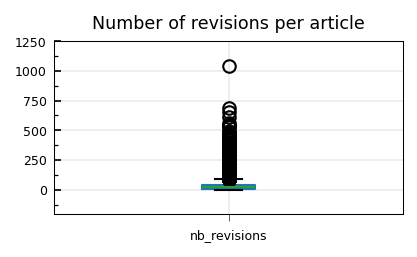

In [17]:
# Number of contributions per article
display(df[["nb_revisions"]].describe())
ax = df.boxplot("nb_revisions")
ax.set_title("Number of revisions per article")

,nb_contributors
count,7292.000000
mean,14.145091
std,12.648354
min,1.000000
25%,2.000000
50%,13.000000
75%,21.000000
max,128.000000


Text(0.5, 1.0, 'Number of contributors per article')

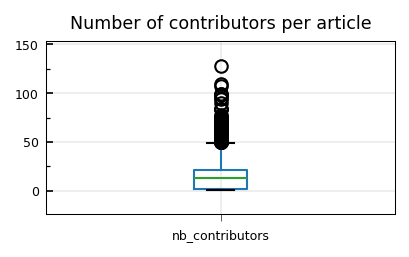

In [18]:
# Number of unique contributors per article
display(df[["nb_contributors"]].describe())
ax = df.boxplot("nb_contributors")
ax.set_title("Number of contributors per article")

# Dialect distribution

In [19]:
dialect_to_code = {
    "lengadocian": "LAN",
    "provençau": "PRO",
    "gascon": "GAS",
    "auvernhat": "AUV",
    "lemosin": "LIM",
    "vivaroaupenc": "VIV",
    "niçard": "NIC",
    "aranés": "ARA",
    "aguiainés": "AGUI",
    "marchés": "MAR"
}

In [20]:
dialect_counts_article = df.value_counts("dialect")
gb_dialect_tokens = df.groupby("dialect")["n_toks"].sum().sort_values(ascending=False)

df_counts = pd.DataFrame({"#tokens": gb_dialect_tokens, "#articles": dialect_counts_article})
df_counts.rename(index=dialect_to_code, inplace=True)
df_counts.sort_values(by="#tokens", ascending=False, inplace=True)

df_counts

,#tokens,#articles
dialect,,
PRO,2068477,2152
LAN,937250,2149
GAS,644551,1920
AUV,160480,399
LIM,96769,254
VIV,59504,237
NIC,53817,142
ARA,16606,37
MAR,343,1


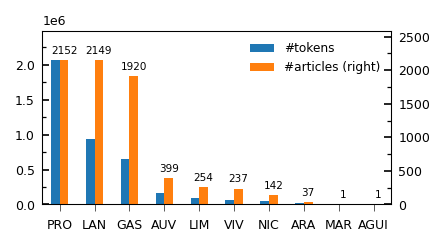

In [21]:
# Plot
ax = df_counts.plot(kind="bar", secondary_y="#articles", rot=0, figsize=(3, 1.5)) # logy=True)
ax.set_xlabel("")
rax = ax.right_ax
rax.bar_label(rax.containers[0], padding=2, fontsize=5)

# Save to PDF and PNG
plt.savefig(os.path.join(plots_folder, "dist_dialects"))
plt.savefig(os.path.join(plots_folder, "dist_dialects.png"), format="png", dpi=300)

## Relation between article dialect and user dialects

In [22]:
# Count for each dialect the number of articles where at least 
# one contribution was made by an author declaring the same dialect as the article's dialect tag
match_key = "#udmatch"
counter_dialects = defaultdict(lambda: {match_key: 0, "#articles": 0})
for _, article in df.iterrows():
    true_dia = article["dialect"]
    counter_dialects[true_dia]["#articles"] += 1
    m_dialect = true_dia in article["user_dialects"] if article["user_dialects"] else False
    if m_dialect:
        counter_dialects[true_dia][match_key] += 1

df_user_dialects = pd.DataFrame.from_dict(counter_dialects, orient="index")
df_user_dialects["ratio"] = df_user_dialects.apply(lambda row: round(100 * row[match_key] / row["#articles"], 2), axis=1)
df_user_dialects.rename(index=dialect_to_code, inplace=True)

# Get number of users declaring each dialect
user_dia_counts = df_users[df_users["is_active"]].groupby("dialect")["dialect"].count().to_frame("#users").rename(index=dialect_to_code)
df_user_dialects = df_user_dialects.join(user_dia_counts)
df_user_dialects["#users"] = df_user_dialects["#users"].fillna(0).astype(int)

# Sort by total nb articles
df_user_dialects.sort_values(by="#articles", ascending=False, inplace=True)

df_user_dialects

,#udmatch,#articles,ratio,#users
PRO,1949,2152,90.57,8
LAN,1236,2149,57.52,13
GAS,1525,1920,79.43,10
AUV,13,399,3.26,2
LIM,176,254,69.29,2
VIV,0,237,0.00,0
NIC,0,142,0.00,0
ARA,0,37,0.00,0
MAR,0,1,0.00,0
AGUI,0,1,0.00,0


In [23]:
tot_user_dialect_decl = df_user_dialects["#users"].sum()
print(f"{tot_user_dialect_decl} users declared a dialect")

35 users declared a dialect


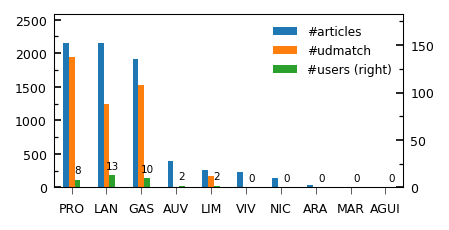

In [24]:
# Plot article dialect tag + user dialect
ax = df_user_dialects[["#articles", match_key, "#users"]].plot(kind="bar", secondary_y="#users", rot=0, figsize=(3, 1.5))
ax.set_xlabel("")
rax = ax.right_ax
# ax.bar_label(ax.containers[1], padding=2, fontsize=5)
rax.bar_label(rax.containers[0], padding=2, fontsize=5)
rax.set_ylim(0, len(df_users)/len(df_user_dialects))

# Save to PDF and PNG
plt.savefig(os.path.join(plots_folder, "user_dialects"))
plt.savefig(os.path.join(plots_folder, "user_dialects.png"), format="png", dpi=300)

# Language levels

[Text(0, 3, '1122'),
 Text(0, 3, '43'),
 Text(0, 3, '32'),
 Text(0, 3, '23'),
 Text(0, 3, '12'),
 Text(0, 3, '12'),
 Text(0, 3, '4'),
 Text(0, 3, '1')]

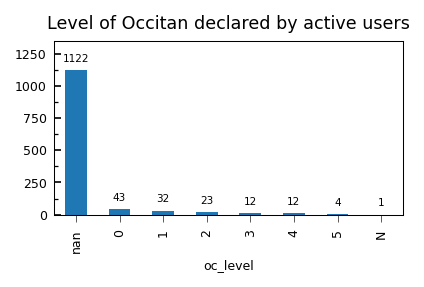

In [25]:
# Plot distribution of language levels among active users
ax = df_users[df_users["is_active"] == True].value_counts("oc_level", dropna=False).plot(kind="bar", title="Level of Occitan declared by active users")
ax.bar_label(ax.containers[0], padding=3, fontsize=5)

In [26]:
def get_numeric_oc_level(lvl):
    if lvl == "None":
        return 0
    elif lvl == "N":
        return 6
    else:
        return int(lvl)

def get_oc_level_diff(row):
    lf = get_numeric_oc_level(row["oc_level_first"])
    lm = get_numeric_oc_level(row["oc_level_max"])
    return lm - lf

# Count first levels
first_level_counts = df.value_counts("oc_level_first", dropna=False).to_frame("#first").sort_index()

# Count max levels
max_level_counts = df.value_counts("oc_level_max", dropna=False).to_frame("#max").sort_index()

# Compute differences max-first
df["oc_level_diff"] = df.apply(get_oc_level_diff, axis=1)
diff_mean = {name: group['oc_level_diff'].median() for name, group in df.groupby('oc_level_first')}

# Merge
df_level_counts = first_level_counts.join(max_level_counts, how="outer").fillna(0).astype(int)
df_level_counts["diff_median"] = diff_mean
df_level_counts["diff_median"] = df_level_counts["diff_median"].fillna(0)

df_level_counts

,#first,#max,diff_median
0,38,22,2.0
1,9,14,3.0
2,3334,3349,0.0
3,58,78,1.0
4,38,3045,0.0
5,6,350,0.0
N,0,5,0.0
None,3809,429,4.0


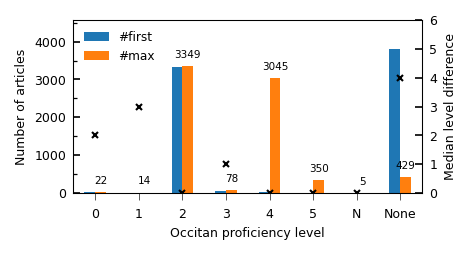

In [27]:
# Plot oc_level in articles: bars + dots
ax = df_level_counts[["#first", "#max"]].plot(kind="bar", rot=0, figsize=(3, 1.5))
ax.bar_label(ax.containers[1], padding=3, fontsize=5)
ax.set_ylabel('Number of articles')
plt.xlabel("Occitan proficiency level")

# Plot the dots on the secondary axis
ax2 = ax.twinx()
ax2.plot(df_level_counts.index, df_level_counts['diff_median'], 'x', color="black", markersize=3)
ax2.yaxis.minorticks_off()
ax2.set_ylim(0, 6)
ax2.set_ylabel('Median level difference')

# Save to PDF and PNG
plt.savefig(os.path.join(plots_folder, "dist_levels"))
plt.savefig(os.path.join(plots_folder, "dist_levels.png"), format="png", dpi=300)
plt.show()

# Bot contributions

In [28]:
# Number of detected bots among active users
bot_users = df_users[(df_users["is_active"] == True) & (df_users["is_bot"] == True)]
print(f"Detected {len(bot_users)} bots among active users.")

Detected 135 bots among active users.


In [29]:
# Get nb articles created by a bot (first contribution, might be empty)
bot_created = df.value_counts("bot_created", normalize=True, dropna=False).loc[1]
print(f"{bot_created:.2%} articles were created by a detected bot (1st contribution)")

13.36% articles were created by a detected bot (1st contribution)


In [30]:
# Get ratio of total contributions
def get_contrib_bot_ratio(min_diff=0):
    db_cur = db_con.cursor()
    q = "SELECT COUNT(*) FROM contribution"
    if min_diff:
        q += " WHERE contribution.diff_bytes > :min_diff"
        res = db_cur.execute(q, {"min_diff": min_diff})
    else:
        res = db_cur.execute(q)
    total_contributions = res.fetchone()[0]
    
    q = """SELECT COUNT(*) FROM contribution
    JOIN user ON user.id = contribution.user_id
    WHERE user.is_bot == 1"""
    if min_diff:
        q += " AND contribution.diff_bytes > :min_diff"
        res = db_cur.execute(q, {"min_diff": min_diff})
    else:
        res = db_cur.execute(q)
    bot_contributions = res.fetchone()[0]
    
    ratio_bot_contributions = bot_contributions / total_contributions
    print(f"Bot contributions ({bot_contributions}) account for "
        f"{ratio_bot_contributions:.2%} of all contributions "
        f"({total_contributions}) - min_diff={min_diff}")

get_contrib_bot_ratio(min_diff=0)

Bot contributions (109322) account for 41.29% of all contributions (264743) - min_diff=0


In [31]:
# >100 bytes
get_contrib_bot_ratio(min_diff=100)

Bot contributions (8273) account for 13.65% of all contributions (60588) - min_diff=100


In [32]:
# >200 bytes
get_contrib_bot_ratio(min_diff=200)

Bot contributions (7359) account for 15.89% of all contributions (46318) - min_diff=200


In [33]:
# Get nb articles first authored by a bot (i.e. first non-empty contribution)
bot_first_author = df.value_counts("bot_first_author", normalize=True, dropna=False).loc[1]
print(f"{bot_first_author:.2%} articles were first authored by a detected bot (1st contribution where the article length is >=100 bytes)")

7.57% articles were first authored by a detected bot (1st contribution where the article length is >=100 bytes)


# Show samples per dialect

In [34]:
# Get list of dialects
dialects = sorted(df["dialect"].unique())

In [35]:
# Get the paragraph-level dataset
df_pars = df.explode("paragraphs", ignore_index=True)[["id", "title", "dialect", "paragraphs", "oc_level_max"]]
df_pars.rename(columns={"paragraphs": "text"}, inplace=True)
df_pars

,id,title,dialect,text,oc_level_max
0,1,Animalia,vivaroaupenc,# Animalia\nExemples d'animaus de classas divè...,4
1,1,Animalia,vivaroaupenc,## Biologia e caracteristicas\nLa mager part d...,4
2,1,Animalia,vivaroaupenc,### Cellulas e teissuts biologics\nLa cellula ...,4
3,1,Animalia,vivaroaupenc,### Forma e mobilitat\nLa mager part dels anim...,4
4,1,Animalia,vivaroaupenc,### Reproduccion e cicle de vita\nExceptats lo...,4
...,...,...,...,...,...
57415,199685,In-quarto,provençau,"## Bibliografia\n- (fr) Paule Brunot-Fieux, L'...",2
57416,199686,In-octavo,provençau,# In-octavo\nL’in-octavo ò in-8 es un format d...,2
57417,199686,In-octavo,provençau,"## Bibliografia\n- (fr) Ferdinand Giraldon, Le...",2
57418,199687,ISO 216,provençau,# ISO 216\nL’ISO 216 es una nòrma internaciona...,2


In [36]:
@ipywidgets.interact(
    dialect=ipywidgets.Dropdown(options=dialects, description="Dialect:"),
    sample_i=ipywidgets.IntText(value=0, min=0, max=len(df_pars), step=1, description="Sample n°:")
)
def show_sample(dialect, sample_i):
    # Filter samples by dialect
    subset = df_pars[df_pars["dialect"] == dialect]

    print(f"Subset contains {len(subset)} samples\n")

    # Get selected sample
    if sample_i >= len(subset):
        sample_i = len(subset) - 1
        warnings.warn(f"Reached end of subset")
    
    sample = subset.iloc[sample_i]
    
    print(f"Sample n° {sample_i} (id {sample.name})")

    for meta_name, meta_val in sample.items():
        if meta_name == "text":
            continue
        print(f"\t- {meta_name}: {meta_val}")

    print(f"\n{sample['text']}")

interactive(children=(Dropdown(description='Dialect:', options=('aguiainés', 'aranés', 'auvernhat', 'gascon', …